# MantiQ-Auth: Cryptographic Authentication System for Medical Images

Welcome to the **MantiQ-Auth** evaluation notebook.

This notebook demonstrates a purely deterministic **Cryptographic Hash-Based Authentication** pipeline for medical images.

## Key Architectural Pillars:
1. **Primary Authentication**: A deterministic verification flow using Robust Perceptual Hashing (ResNet-18 + Median Quantization + BCH-511 Error Correction + SHA3-256) combined with **Hybrid Signatures** (ECDSA-P256 + ML-DSA-65).
2. **Zero-AI Verification Decision**: Machine learning classifiers (like SVM) are excluded from the authentication decision loop. Authentication strictly requires `RecomputedHash == SignedHash` AND valid cryptographic signatures.
3. **Secondary Analysis**: Predictive AI models are strictly reserved for post-hoc tampering difficulty analysis.

---

## 1. Setup and Environment Check

Verify the cryptographic and machine learning dependencies.

In [1]:
import sys
from pathlib import Path
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML

sys.path.insert(0, str(Path.cwd()))

try:
    import bchlib
    bch_status = "Available ✅"
except ImportError:
    bch_status = "Not Available ❌"

try:
    import oqs
    oqs_status = "Available ✅ (liboqs-python)"
except ImportError:
    oqs_status = "Not Available ❌"

print(f"PyTorch: {torch.__version__}")
print(f"BCH Library: {bch_status}")
print(f"Quantum-Resistant Signatures (OQS): {oqs_status}")

liboqs-python faulthandler is disabled


PyTorch: 2.12.0+cpu
BCH Library: Available ✅
Quantum-Resistant Signatures (OQS): Available ✅ (liboqs-python)


## 2. End-to-End Cryptographic Authentication Demonstration

This runs the pure Hash-Based Verifier to generate and verify a hybrid signature on a medical image.

In [2]:
from src.crypto_gateway import CryptoGateway

# Locate metadata and select a sample image
sample_dir = Path("data/sample/processed/ct")
if sample_dir.exists() and any(sample_dir.iterdir()):
    sample_path = next(sample_dir.glob("*.png"))
    print(f"Selected sample: {sample_path.name}")
    
    # Initialize Gateway using purely hash-based logic
    gateway = CryptoGateway(feature_extractor="resnet", mldsa_level=65)
    gateway.generate_keys()
    
    # Authenticate (Sign)
    auth_res = gateway.authenticate_image(sample_path)
    print("\n--- Cryptographic Signature Created ---")
    print(f"Robust Hash (SHA3-256): {auth_res.robust_hash}")
    print(f"ECDSA Signature Size: {auth_res.signature.ecdsa_size} bytes")
    print(f"ML-DSA-65 Signature Size: {auth_res.signature.mldsa_size} bytes")
    
    # Verify (Unmodified)
    overall, hash_ok, ecdsa_ok, mldsa_ok = gateway.verify_image(
        sample_path, auth_res.robust_hash, auth_res.signature
    )
    print("\n--- Verification (Unmodified Image) ---")
    print(f"Overall: {overall} (Hash Match={hash_ok}, ECDSA={ecdsa_ok}, ML-DSA={mldsa_ok})")
else:
    print("Sample image not found.")

Selected sample: 1.3.6.1.4.1.14519.5_00000056.png



--- Cryptographic Signature Created ---
Robust Hash (SHA3-256): 2ea7fe041aed699d68ba51d1e49eb4c8c8055a19ca66640e7b30ccbe89e7a51c
ECDSA Signature Size: 70 bytes
ML-DSA-65 Signature Size: 3309 bytes

--- Verification (Unmodified Image) ---
Overall: True (Hash Match=True, ECDSA=True, ML-DSA=True)


## 3. Simulating Malicious Tampering

Let's see what happens when the image is maliciously altered. We'll pick a tampered version of the sample image and verify it against the original's signature.

In [3]:
tampered_dir = Path("data/sample/tampered/ct_baseline")
if tampered_dir.exists() and any(tampered_dir.glob("*.png")):
    tampered_path = next(tampered_dir.glob("*.png"))
    print(f"Selected tampered image: {tampered_path.name}")
    
    # Attempt to verify the TAMPERED image using the ORIGINAL signature
    overall_t, hash_ok_t, ecdsa_ok_t, mldsa_ok_t = gateway.verify_image(
        tampered_path, auth_res.robust_hash, auth_res.signature
    )
    print("\n--- Verification (Tampered Image) ---")
    print(f"Overall: {overall_t} (Hash Match={hash_ok_t}, ECDSA={ecdsa_ok_t}, ML-DSA={mldsa_ok_t})")
    print("Notice that the Hash Match fails, thus preventing authentication.")
else:
    print("Tampered sample image not found.")

Selected tampered image: tampered_0007_crop_rescale.png

--- Verification (Tampered Image) ---
Overall: False (Hash Match=False, ECDSA=True, ML-DSA=True)
Notice that the Hash Match fails, thus preventing authentication.


## 4. Comprehensive Evaluation: Hash Matching under Benign vs Malicious Transformations
We now run the evaluation script to evaluate False Positives (benign modification rejection) and True Positives (malicious tampering detection).

In [4]:
!python scripts/run_evaluation.py --images data/sample/processed/ct

[2026-06-09 20:16:23] INFO     mantiq.eval â€” Running evaluation on 5 images...

                 MantiQ-Auth Evaluation Suite (NCC & BER)

ðŸ“� Determinism Check...
[2026-06-09 20:16:30] INFO     mantiq.hash â€” Computing robust hash for: 1.3.6.1.4.1.14519.5_00000056.png
[2026-06-09 20:16:30] INFO     mantiq.features â€” Loading ResNet-18 on cpu...
[2026-06-09 20:16:30] INFO     mantiq.features â€” ResNet-18 loaded and frozen (512-dim features).
[2026-06-09 20:16:31] INFO     mantiq.hash â€” Extracted 512-dim features using resnet.
[2026-06-09 20:16:31] INFO     mantiq.hash â€” Robust hash: 2ea7fe041aed699d68ba51d1e49eb4c8c8055a19ca66640e7b30ccbe89e7a51c
[2026-06-09 20:16:31] INFO     mantiq.hash â€” Computing robust hash for: 1.3.6.1.4.1.14519.5_00000056.png
[2026-06-09 20:16:31] INFO     mantiq.hash â€” Extracted 512-dim features using resnet.
[2026-06-09 20:16:31] INFO     mantiq.hash â€” Robust hash: 2ea7fe041aed699d68ba51d1e49eb4c8c8055a19ca66640e7b30ccbe89e7a51c
[2026-06-09 20:

## 5. Post-hoc Analysis: ML Sensitivities to Subtle Tampering

While authentication is strictly deterministic and hash-based, we provide an SVM-based analysis of the extracted ResNet-18 features. This demonstrates the intrinsic separability and robustness of the features against subtle tampering (the 'hard' dataset).

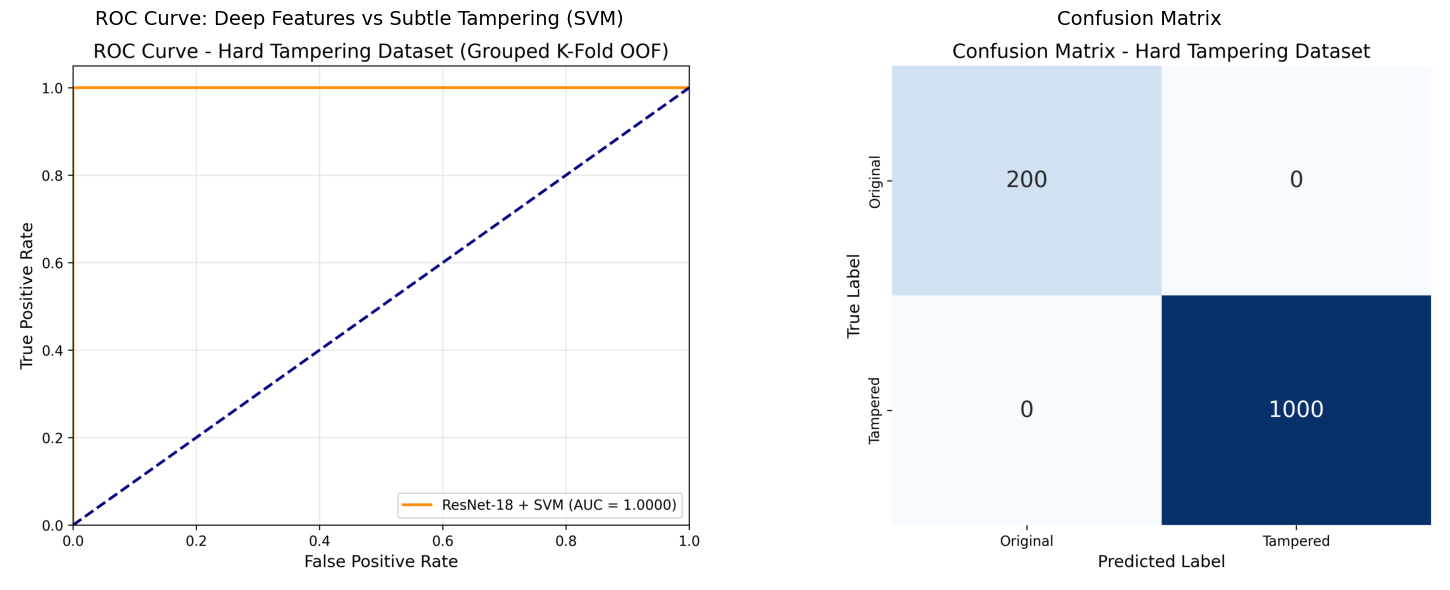

In [5]:
roc_plot = Path("output/hard_dataset_results/roc_curve_hard.png")
cm_plot = Path("output/hard_dataset_results/confusion_matrix_hard.png")

if roc_plot.exists() and cm_plot.exists():
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    axes[0].imshow(Image.open(roc_plot))
    axes[0].axis('off')
    axes[0].set_title("ROC Curve: Deep Features vs Subtle Tampering (SVM)", fontsize=14)
    
    axes[1].imshow(Image.open(cm_plot))
    axes[1].axis('off')
    axes[1].set_title("Confusion Matrix", fontsize=14)
    
    plt.tight_layout()
    plt.show()
else:
    print("Plots not found. They might not have been generated yet in the output/ directory.")

## 6. Conclusion

The MantiQ-Auth system successfully integrates deep visual features with robust perceptual hashing and hybrid post-quantum signatures. By shifting from predictive machine learning classifiers to strict cryptographic hash matching, the system provides deterministic security guarantees: it allows benign transformations (like standard JPEG compression) via bounded error-correction (BCH) while reliably detecting malicious content manipulation.